# 07 · Time–frequency analysis and ERD/ERS

**ROBT613 · Brain–Computer Interfaces** | Academic tutorial and independent exercises

## Goal
Compute wavelet power, normalize it to a pre-cue interval and interpret sensorimotor desynchronization.

**Data:** MNE EEGBCI subject 1, run 4

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Paradigm background and experimental design

### Motor imagery and sensorimotor rhythms

Motor imagery is the internal rehearsal of movement without overt execution. In a sensorimotor-rhythm BCI, the intended action is inferred from changes in oscillatory activity, commonly within the mu and beta ranges. Event-related desynchronization denotes reduced band power relative to a reference interval; it does not mean that the EEG voltage becomes uniformly negative. The spatial and temporal distributions are variable across participants and trials.

A minimal cue-based experiment presents a fixation interval followed by a left- or right-hand instruction, an imagery interval and a rest interval. The participant imagines the kinesthetic sensation of movement while maintaining posture. An EEG cap, amplifier and acquisition computer record continuous signals; a stimulus computer records cue onset and class. Additional EOG or EMG channels, when actually acquired, can support artifact assessment. Their presence must not be assumed from scalp EEG alone.

A trial is one instructed imagery interval; a run is a sequence of trials; a session is a recording visit. These levels are not exchangeable independent samples. Run-wise evaluation assesses transfer across recording blocks, whereas subject-wise evaluation addresses a different generalization claim. Averaging signed voltages can suppress induced rhythms whose phases vary between trials; band power or time–frequency estimates are therefore central measurements.

### Acquisition provenance and instructional protocol

PhysioNet EEGBCI: 64 scalp channels, 160 Hz. Runs 4, 8 and 12 encode imagined left/right fist movement; individual lessons may use only run 4. Acquisition used BCI2000. The original database also contains executed movements and other imagery tasks.

**Acquisition reference:** [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). The sampling rate of processed epochs can differ from the original acquisition rate after explicit resampling.

| Experimental component | Required record and analytical purpose |
|---|---|
| Participant instruction | Defines the task and distinguishes attention, imagery and execution |
| Stimulus/event clock | Provides onset markers for alignment; its synchronization must be documented |
| Measurement hardware | Records sensor type, locations, reference and original sampling frequency |
| Trial, run and session log | Preserves dependence structure and supports appropriate validation |
| Quality observations | Records movement, contact failures and rejected intervals without changing labels |

**Experimental sequence:** Cue and task instruction → continuous EEG → imagery epoch → spectral/spatial features. Exact cue durations and hardware settings must be obtained from the original protocol; the analysis windows below are explicitly chosen processing intervals.

### Measurement model and interpretation

For EEG, a sensor measures a potential difference, not neuronal firing rate. The observed signal combines neural activity, physiological interference, environmental interference and measurement noise. Filtering or projection changes this mixture and cannot establish that the remaining signal is exclusively neural. For fNIRS, replace the electrical measurement model with the optical model defined below. Experimental labels are external observations; they must not be reconstructed from a classifier's predictions.

### Mathematical definitions for this lesson

For wavelet $\psi_f$, $W_i(c,f,t)=(x_{ic}*\psi_f)(t)$ and $P_i(c,f,t)=|W_i(c,f,t)|^2$. Let $B_i(c,f)$ be mean baseline power. Relative power is $100(P_i-B_i)/B_i$ percent; decibel change is $10\log_{10}(P_i/B_i)$. Negative values indicate reduced power under these conventions. The logarithm of an average and the average of logarithms are generally unequal; the order of normalization and averaging must be stated.

Throughout, $i$ indexes trials, $c$ channels, $k$ samples, $N$ trials, $C$ channels and $T$ samples per trial unless a local definition states otherwise. An EEG epoch array has shape $(N,C,T)$; classifier features have shape $(N,d)$. A change of representation must preserve the correspondence between observations and labels.


**Methodological reading:** [Pfurtscheller and Lopes da Silva (1999). Event-related EEG/MEG synchronization and desynchronization: basic principles](https://doi.org/10.1016/S1388-2457(99)00141-8). Physiological and quantitative basis of ERD/ERS.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Complete the analytical task in its workspace.
4. Continue to the worked solution and compare the reasoning, as well as the numerical result.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Independent exercise” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## Analytical objectives

This lesson examines the relationship between the experimental task, the measured signal and the assumptions of the analysis. Interpret each computational result in relation to the acquisition protocol and the stated evaluation design.

### Learning outcomes

- Explain the time–frequency resolution tradeoff.
- Distinguish averaging signals from averaging their power.
- Calculate relative power change in percent and decibels.
- Interpret ERD maps with their baseline and edge limitations.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

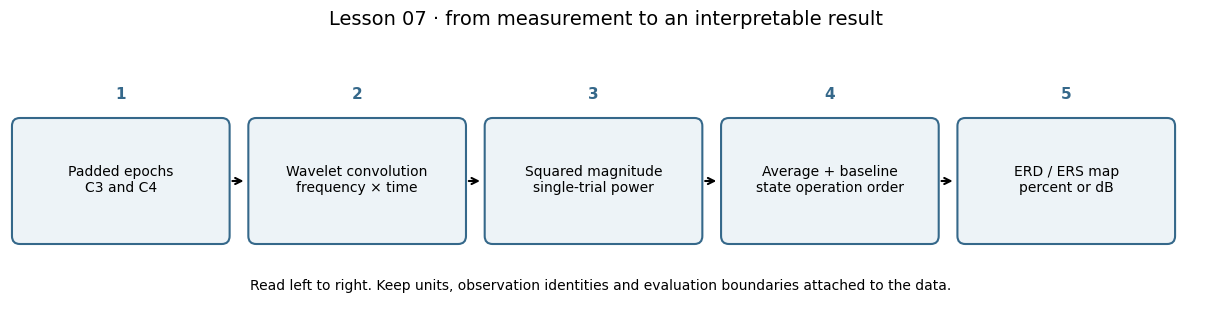

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Padded epochs\nC3 and C4', 'Wavelet convolution\nfrequency × time', 'Squared magnitude\nsingle-trial power', 'Average + baseline\nstate operation order', 'ERD / ERS map\npercent or dB']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 07 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Padded epochs: C3 and C4 → Wavelet convolution: frequency × time → Squared magnitude: single-trial power → Average + baseline: state operation order → ERD / ERS map: percent or dB.

## Symbols and a calculation by hand

$Z(f,t)$: complex wavelet coefficient; $P=|Z|^2$: power; $P_B$: baseline power; $n_c$: cycles.

### Derive the operation before calling the library

A Morlet kernel has temporal standard deviation $\sigma_t=n_c/(2\pi f)$. At 10 Hz with five cycles, $\sigma_t\approx0.0796$ s; the full kernel spans several such standard deviations. Increasing the cycle count doubles temporal spread when frequency is fixed.

For baseline power 10 and task power 5, percent change is $100(5/10-1)=-50\%$, while dB change is $10\log_{10}(0.5)\approx-3.01$. Neither means negative physical power. Two opposite-phase coefficients $Z_1=1$ and $Z_2=-1$ have zero squared average, but average squared magnitude one. This is why evoked power and total power must not be interchanged.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### Why a spectrum is not enough

A Fourier spectrum describes how signal energy is distributed across frequency over the analyzed interval. If 10 Hz activity is strong before an event and weak afterward, one spectrum averages over both states. Time-frequency analysis moves a frequency-sensitive window through the recording. The result has trial, channel, frequency and time axes; every later average should name which of these it removes.

A complex Morlet wavelet combines an oscillation with a Gaussian envelope:

$$\psi_f(t)=e^{i2\pi ft}\exp[-t^2/(2\sigma_t^2)],\qquad \sigma_t=\frac{n_{cycles}}{2\pi f}.$$

Convolution gives a complex coefficient $Z(f,t)$; power is $|Z(f,t)|^2$. More cycles improve frequency selectivity but spread information across a longer time interval. Fewer cycles localize a change more sharply but blur nearby frequencies. The effective kernel extends beyond one standard deviation; do not interpret $\sigma_t$ as the entire support.

In this lesson `n_cycles = freqs / 2` makes the ratio $n_{cycles}/f$ constant. It therefore keeps the approximate temporal width constant across frequencies. A fixed cycle count would instead make lower-frequency wavelets longer. Neither choice is universally correct: select it according to the time and frequency changes you wish to resolve.

### Total and evoked power answer different questions

Averaging trial signals preserves activity with consistent phase and latency. Averaging single-trial power preserves energy even if phase varies. In general,

$$\left|\frac{1}{N}\sum_n Z_n\right|^2\ne\frac{1}{N}\sum_n|Z_n|^2.$$

The first is power of the averaged response; the second is average total power. A rhythm can be strong in every trial yet disappear from the averaged waveform if its phase is not locked to the event. Conversely, a sharp evoked transient contributes broadband time-frequency power without being a sustained oscillation.

### ERD is a comparison with a baseline

Let $P_B(f)$ be mean baseline power at frequency $f$. Two common transformations are

$$\Delta P_{\%}=100\frac{P-P_B}{P_B},\qquad \Delta P_{dB}=10\log_{10}\frac{P}{P_B}.$$

A negative value indicates less power than the chosen baseline. It does not mean negative physical power. A 50% decrease is approximately −3.01 dB; a 50% increase is approximately +1.76 dB. Equal percentage changes upward and downward are not symmetric in decibels.

Compute baseline estimates from a defensible pre-event interval and retain enough surrounding data for convolution. Wavelets centered near an epoch edge have incomplete support and can be distorted by padding. The lesson computes on a wider interval and displays a narrower one. The resulting C3/C4 maps are descriptive sensor-level summaries, not localization or proof of a causal mechanism.

## Visual intuition · See a rhythm disappear in time and frequency

**Independent exercise:** The 10 Hz amplitude changes halfway through the trace. Predict the approximate power reduction and where a finite window will blur its onset.

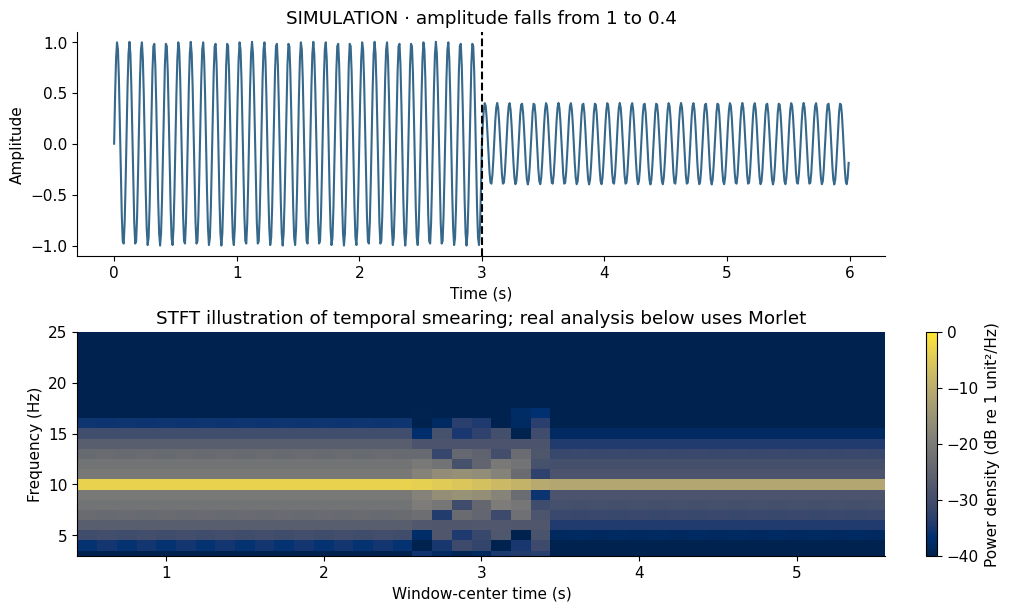

In [3]:
vis_fs=128;vis_t=np.arange(768)/vis_fs
vis_amp=np.where(vis_t<3,1.,.4)
vis_x=vis_amp*np.sin(2*np.pi*10*vis_t)
vis_f,vis_tt,vis_S=signal.spectrogram(vis_x,fs=vis_fs,nperseg=128,noverlap=112)
fig,axes=plt.subplots(2,1,figsize=(10,6),constrained_layout=True)
axes[0].plot(vis_t,vis_x,color='#35688a');axes[0].axvline(3,color='black',ls='--')
axes[0].set(xlabel='Time (s)',ylabel='Amplitude',title='SIMULATION · amplitude falls from 1 to 0.4')
vis_im=axes[1].pcolormesh(vis_tt,vis_f,10*np.log10(np.maximum(vis_S,1e-8)),shading='auto',cmap='cividis',vmin=-40,vmax=0)
axes[1].set(ylim=(3,25),xlabel='Window-center time (s)',ylabel='Frequency (Hz)',title='STFT illustration of temporal smearing; real analysis below uses Morlet')
fig.colorbar(vis_im,ax=axes[1],label='Power density (dB re 1 unit²/Hz)');plt.show()

### Worked interpretation

Amplitude falls to 0.4, so power falls to 0.16 of baseline: an 84% decrease or about −7.96 dB. The change is smeared near 3 s because each spectral window spans time on both sides. This is a qualitative illustration, not the exact Morlet kernel used later.

## Guided practice 1 · phase cancellation

Create two equally strong rhythms in opposite phase. Compare the power of their average with their average power.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_t=np.arange(1000)/100
demo_trials=np.stack([np.sin(2*np.pi*10*demo_t),-np.sin(2*np.pi*10*demo_t)])
print('Power of average:',np.mean(demo_trials.mean(axis=0)**2))
print('Average power:',np.mean(demo_trials**2))

Power of average: 0.0
Average power: 0.4999999999999995


### Why this result makes sense

Zero evoked power does not imply absence of oscillatory activity in the trials.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · the same change in two units

Use baseline power 10 and task powers 5, 10 and 15. Predict the signs and ordering.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_baseline=10.
demo_task=np.array([5.,10.,15.])
print(pd.DataFrame({'power':demo_task,'percent':100*(demo_task/demo_baseline-1),'dB':10*np.log10(demo_task/demo_baseline)}))

   power  percent        dB
0    5.0    -50.0 -3.010300
1   10.0      0.0  0.000000
2   15.0     50.0  1.760913


### Why this result makes sense

The baseline maps to zero in both relative representations. The underlying powers remain positive.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · wavelet width

Compare fixed cycles with cycles proportional to frequency. Keep track of seconds rather than only the cycle count.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_f=np.array([6.,10.,20.,30.])
print(pd.DataFrame({'Hz':demo_f,'sigma_s_fixed_5':5/(2*np.pi*demo_f),'sigma_s_proportional':(demo_f/2)/(2*np.pi*demo_f)}))

     Hz  sigma_s_fixed_5  sigma_s_proportional
0   6.0         0.132629              0.079577
1  10.0         0.079577              0.079577
2  20.0         0.039789              0.079577
3  30.0         0.026526              0.079577


### Why this result makes sense

At low frequencies, fixed-cycle kernels are longer. Baseline and epoch margins should accommodate the longest relevant kernel.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · order of averaging

Compare taking a mean after a log with taking a log after a mean.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_p=np.array([1.,9.])
print('Mean log power:',np.log10(demo_p).mean())
print('Log mean power:',np.log10(demo_p.mean()))

Mean log power: 0.47712125471966244
Log mean power: 0.6989700043360189


### Why this result makes sense

Nonlinear transforms do not commute with averaging. State whether the reported map is transformed mean power or mean transformed power.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · dB conversion

Implement relative_db for positive power and baseline arrays using broadcasting.

**Independent exercise:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def relative_db(power, baseline):
    # TODO: return a power ratio in decibels.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def relative_db(power,baseline):
    return 10*np.log10(np.asarray(power)/baseline)

In [10]:
answer=relative_db(np.array([5.,10.,20.]),10.)
if answer is not None:
    assert np.allclose(answer,[-3.01029996,0,3.01029996]); print('dB checks passed.')
else: print('Exercise pending: implement relative_db.')

dB checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

The Morlet wavelet is a complex sinusoid multiplied by a Gaussian: $\psi_f(t)=e^{j2\pi ft}e^{-t^2/(2\sigma_t^2)}$. Time-frequency power is $P(f,t)=|x*\psi_f|^2$. With $n_c$ cycles, $\sigma_t\approx n_c/(2\pi f)$: more cycles sharpen frequency resolution but blur timing.

Baseline-relative power is $10\log_{10}[P(f,t)/P_B(f)]$ in dB. Negative values indicate less power than baseline (ERD); positive values indicate more (ERS). This is a ratio of power, not voltage. Averaging power before normalizing is not generally equivalent to averaging trialwise ratios. We explicitly average trial power first.

Convolution uses data around each point. Pad epochs and interpret only their interior. A late cue-locked difference can be physiological, while a pre-cue difference can come from filtering/wavelet temporal spread or experimental anticipation. No inferential significance is implied by a color plot.

## Load longer epochs for padding
Keep a pre-cue reference and an interior analysis window.

Epochs include extra time around the interval to be displayed. That margin provides support for wavelet convolution and reduces reliance on edge padding in the plotted interior.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Fetch only the specified participant/run files; the cache prevents repeat downloads.

**3.** Read continuous voltage samples and metadata into an MNE Raw object.

**4.** Standardize dataset channel names so later sensor-name selection is meaningful.

**5.** Attach sensor coordinates; this does not perform anatomical source localization.

**6.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**7.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [11]:
# Import the named tools used in this step.
from mne.datasets import eegbci
# Fetch only the specified participant/run files; the cache prevents repeat downloads.
files = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False)
# Read continuous voltage samples and metadata into an MNE Raw object.
raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
# Standardize dataset channel names so later sensor-name selection is meaningful.
eegbci.standardize(raw)
# Attach sensor coordinates; this does not perform anatomical source localization.
raw.set_montage('standard_1005')
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(raw)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Channel types:', set(raw.get_channel_types()))

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Channel types: {'eeg'}


/tmp/ipykernel_476639/1909471534.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


### Step 1.2 · trace the next operation

**1.** Apply the declared frequency filter; copy first when the original must be preserved.

**2.** Translate documented annotation descriptions into discrete event codes.

**3.** Create event-aligned trials with the stated interval, baseline and quality rules.

In [12]:
# Apply the declared frequency filter; copy first when the original must be preserved.
raw.filter(2, 40)
# Translate documented annotation descriptions into discrete event codes.
events, _ = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2})
# Create event-aligned trials with the stated interval, baseline and quality rules.
epochs = mne.Epochs(raw, events, {'left': 1, 'right': 2}, -1, 4, baseline=None, picks=['C3', 'C4'], preload=True, reject_by_annotation=True)

### Inspect and interpret

Compare the extraction interval with the final display interval and baseline. Explain why computing only on the displayed range would be a different operation.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Check whether the epoch supports the planned analysis

**Independent exercise:** Print the extracted interval, sampling rate and channel names. Identify the interior interval used in the main plot.

**My reasoning / hand calculation:** _write here._

In [13]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

The extraction interval should be wider than the plotted interval.

### Worked solution

Run the following calculation after attempting your own version.

In [14]:
print('Epoch interval:',epochs.times[[0,-1]],'s')
print('Sampling:',epochs.info['sfreq'],'Hz; sensors:',epochs.ch_names)
print('Display interval: -0.5 to 3.5 s; baseline: -0.8 to -0.2 s')

Epoch interval: [-1.  4.] s
Sampling: 160.0 Hz; sensors: ['C3', 'C4']
Display interval: -0.5 to 3.5 s; baseline: -0.8 to -0.2 s


### Interpret and check

The wider −1 to 4 s epoch provides context outside the displayed interval. This reduces edge dependence but does not prove every point is artifact-free. Kernel support and baseline placement still require inspection.

## Compute and normalize power
The baseline is −0.8 to −0.2 s. We show −0.5 to 3.5 s to reduce edge interpretation.

Power is computed before trial averaging, then normalized against a pre-event baseline. The logarithmic ratio uses positive power estimates; its zero means baseline-level power. Sensor and condition labels remain explicit in the plot.

### Step 2.1 · trace the next operation

**1.** Make the analysis choice visible and fixed before inspecting evaluation performance.

**2.** Apply Morlet kernels and retain single-trial power before averaging.

**3.** Name the intermediate representation so its dimensions can be checked before the next transformation.

**4.** Store this intermediate result so the next operation can be traced and inspected.

In [15]:
# Make the analysis choice visible and fixed before inspecting evaluation performance.
freqs = np.arange(6, 31, 2)
# Apply Morlet kernels and retain single-trial power before averaging.
power = epochs.compute_tfr(method='morlet', freqs=freqs, n_cycles=freqs / 2, return_itc=False, average=False, decim=4)
# Name the intermediate representation so its dimensions can be checked before the next transformation.
P = power.data
# Store this intermediate result so the next operation can be traced and inspected.
baseline = (power.times >= -0.8) & (power.times <= -0.2)

### Step 2.2 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Plot each named condition on comparable axes without changing its observations.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

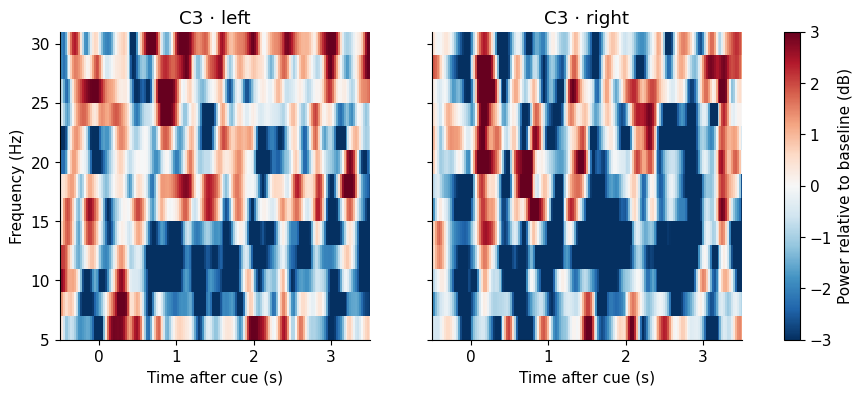

In [16]:
# Create axes; plotting changes the display, not the analyzed data.
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
# Plot each named condition on comparable axes without changing its observations.
for ax, (name, event) in zip(axes, epochs.event_id.items()):
    mean = P[epochs.events[:, 2] == event, 0].mean(0)
    db = 10 * np.log10(mean / mean[:, baseline].mean(1, keepdims=True))
    im = ax.pcolormesh(power.times, freqs, db, cmap='RdBu_r', vmin=-3, vmax=3, shading='auto')
    ax.set(xlim=(-0.5, 3.5), xlabel='Time after cue (s)', title=f'C3 · {name}')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
axes[0].set_ylabel('Frequency (Hz)')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
fig.colorbar(im, ax=axes, label='Power relative to baseline (dB)')
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Identify a region of reduced or increased power and describe its time/frequency extent without implying a perfectly sharp boundary. Explain how wavelet width contributes to that apparent extent.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Extract one trial-level ERD feature

**Independent exercise:** Calculate C3 average power in 8–12 Hz during 0.5–2.5 s relative to the pre-cue baseline for every trial.

**My reasoning / hand calculation:** _write here._

In [17]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Keep the trial dimension; average only frequency and time.

### Worked solution

Run the following calculation after attempting your own version.

In [18]:
lab_band=(freqs>=8)&(freqs<=12)
lab_task=(power.times>=.5)&(power.times<=2.5)
lab_baseline=(power.times>=-.8)&(power.times<=-.2)
lab_task_power=P[:,0,lab_band,:][:,:,lab_task].mean(axis=(1,2))
lab_base_power=P[:,0,lab_band,:][:,:,lab_baseline].mean(axis=(1,2))
lab_erd=10*np.log10(lab_task_power/lab_base_power)
print(pd.DataFrame({'event':epochs.events[:,2],'C3_mu_change_dB':lab_erd}).head(8))
assert lab_erd.shape==(len(epochs),)

   event  C3_mu_change_dB
0      2         0.596307
1      1        -5.046895
2      1        -0.279684
3      2        -4.610619
4      2        -3.034357
5      1         2.081218
6      2        -3.578913
7      1         1.745382


### Interpret and check

This yields one scalar per trial, suitable as a pre-specified feature. It differs from a map formed by averaging all trial power first. If the band/time region is chosen after looking at class separation, select it inside training folds before reporting held-out decoding.

## Practice 4 · Explain a negative color in the ERD map

**Independent exercise:** Does −3 dB mean the signal has negative power? Give the ratio corresponding to −3 dB.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Invert dB = 10 log10(ratio).

### Worked solution

Power remains nonnegative. A −3 dB change corresponds to $10^{-3/10}\approx0.501$ times baseline power. The sign describes the comparison with a baseline, not the sign of the physical energy.

## Practice 5 · Choose cycles for a different question

**Independent exercise:** Would more cycles be preferable for identifying an abrupt onset or for distinguishing close frequencies? Explain the tradeoff.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

A longer oscillatory kernel spans more time.

### Worked solution

More cycles generally improve frequency selectivity while broadening temporal support. Fewer cycles help localize a rapid change but blur frequency distinctions. The choice should follow the question and be reported with the baseline and plotted interval, rather than selected for the most attractive map.

## Recorded-signal inspection with MNE-Python

The following visualization uses the recording analysed in this notebook. The API retains channel names, sample timing and physical units. This is descriptive inspection; it does not authorize selecting parameters on held-out labels.

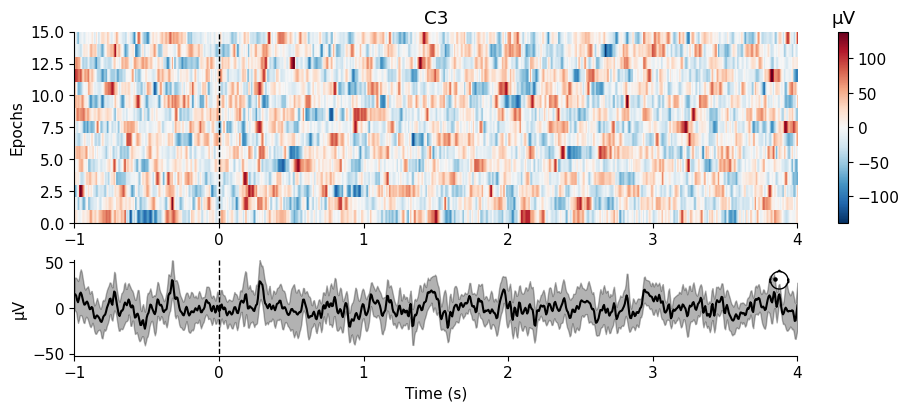

In [19]:
# Display individual recorded trials with MNE's epoch-image API.
inspection_epochs = epochs.copy().pick(['C3'])
inspection_epochs.plot_image(picks=['C3'], sigma=0, show=False)
plt.show()

### Figure interpretation and independent exercise

The image displays individual trials at C3; colour encodes voltage and the lower panel summarizes the evoked response. Inspect amplitude variability and temporal alignment. For motor imagery and SSVEP, a weak signed average can coexist with substantial induced or frequency-locked power; interpret this display alongside the spectral analysis. Trial order follows the loaded epoch object and is not a randomized validation split.

**Exercise.** Identify the measurement unit, the observation represented by each trace or image row, and one conclusion that the figure cannot support. Explain how the answer changes if the signal has already been filtered.

**Reference interpretation.** The displayed observations are processed sensor measurements, not independent participants. Filtering changes the measured bandwidth and temporal structure. The plot supports quality assessment and descriptive comparisons; it does not establish causal neural mechanisms, source location or out-of-sample classification performance.

## Practice 6 · explain the complete method

Independently explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

A time-frequency map combines a kernel’s resolution with the data’s changes. Negative ERD is lower positive power relative to a baseline. Averaging power and taking the power of an average answer different questions and must be named explicitly.

## If your result is different

If a map contains infinities, inspect baseline powers before taking ratios. If changes appear before the event, consider kernel temporal support and offline filtering as well as physiology.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[MNE time-frequency analysis](https://mne.tools/stable/auto_tutorials/time-freq/20_sensors_time_frequency.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.

## References and further reading

1. [Gramfort et al. (2013), MEG and EEG data analysis with MNE-Python](https://doi.org/10.3389/fnins.2013.00267). Core data structures and reproducible electrophysiological analysis.
2. [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). Acquisition provenance, task definition and dataset-specific interpretation.
3. [MNE-Python API reference](https://mne.tools/stable/python_reference.html). Consult the documented units, defaults and return values of each method.
4. [MNE overview tutorial](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Relationship between continuous data, epochs and evoked responses.
5. [MNE documentation on in-place modification](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html). Object copying and preservation of analysis branches.

These references support the acquisition and software descriptions. Numerical outcomes in this notebook refer only to the explicitly selected data and evaluation design; they are not population performance estimates. Dataset terms remain separate from the licence of these teaching materials.


### Primary methodological literature

- [Pfurtscheller and Lopes da Silva (1999). Event-related EEG/MEG synchronization and desynchronization: basic principles](https://doi.org/10.1016/S1388-2457(99)00141-8). Physiological and quantitative basis of ERD/ERS.